# Reproduce Results — ShapeNet Part Segmentation

This notebook reproduces the key tables and figures in our report **without retraining**.
It loads the three trained checkpoints (`pointnet`, `pointnet2`, `dgcnn`) and:

1. Re-evaluates each model on the official ShapeNet test split → reproduces the **main results table**.
2. Re-renders the **per-category mIoU bar chart** (Figure 1).
3. Re-renders the **training curves** (Figure 2) from the saved `history.json` files.
4. Re-runs the **point-density robustness study** (Figure 3).
5. Renders **qualitative segmentation visualizations** (Figure 4).

All outputs are written to `/kaggle/working/reproduced/`.

---

### What you need

- A Kaggle account with GPU enabled (Settings → Accelerator - GPU T4).
- A Kaggle API token saved as a Secret under the name `KAGGLE_API_TOKEN` (Add-ons -> Secrets). The notebook uses this to download ShapeNet (~1.3 GB) automatically on first run — subsequent runs skip the download.
- The `deliverables` dataset attached as a Kaggle input (+ Add Input -> search `deliverables` -> Add). This contains the trained checkpoints.

### Path configuration

All paths are set in the **Configuration** cell at the top of the notebook:

| Variable | Default | What it points to |
|----------|---------|-------------------|
| `DATA_ROOT` | `/kaggle/working/ShapeNet` | Where ShapeNet is downloaded and cached |
| `CKPT_ROOT` | `/kaggle/input/deliverables/all_deliverables/checkpoints` | The three trained checkpoints |
| `OUT_DIR` | `/kaggle/working/reproduced` | Where figures and JSON results are written |

If Kaggle mounts the deliverables dataset at a different path, run `!ls /kaggle/input/` to find the correct folder name and update `CKPT_ROOT`.


In [ ]:
# Authenticate the Kaggle CLI using the API token stored in Kaggle Secrets, so that !kaggle dataset download commands work in this notebook.

from kaggle_secrets import UserSecretsClient
import os

secrets = UserSecretsClient()
token = secrets.get_secret('KAGGLE_API_TOKEN')

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/access_token'), 'w') as f:
    f.write(token)
os.chmod(os.path.expanduser('~/.kaggle/access_token'), 0o600)

# Configuration

In [ ]:
import os
import shutil

DATA_ROOT = '/kaggle/working/ShapeNet'  # dataset
CKPT_ROOT = '/kaggle/input/datasets/nanchan/deliverables/all_deliverables/checkpoints'  # checkpoints
OUT_DIR   = '/kaggle/working/reproduced'

BATCH_SIZE = 16
NUM_WORKERS = 2

os.makedirs(os.path.join(OUT_DIR, 'figures'), exist_ok=True)

# Download ShapeNet dataset, skip if it already exists
RAW_DIR = os.path.join(DATA_ROOT, 'raw')
if not os.path.exists(os.path.join(RAW_DIR, '02691156')):  # airplane folder to check if it already exists
    os.makedirs(RAW_DIR, exist_ok=True)
    print('Downloading ShapeNet (~1.3 GB)...')
    # download Kaggle dataset (it extracts into a nested folder so flatten it)
    !kaggle datasets download -d mitkir/shapenet -p {RAW_DIR} --unzip
    nested = os.path.join(RAW_DIR, 'shapenetcore_partanno_segmentation_benchmark_v0_normal')
    if os.path.isdir(nested):
        for item in os.listdir(nested):
            shutil.move(os.path.join(nested, item), os.path.join(RAW_DIR, item))
        os.rmdir(nested)
    print('Dataset ready.')
else:
    print('Dataset already downloaded.')

print(f'DATA_ROOT = {DATA_ROOT}')
print(f'CKPT_ROOT = {CKPT_ROOT}')
print(f'OUT_DIR   = {OUT_DIR}')

Dataset URL: https://www.kaggle.com/datasets/mitkir/shapenet
License(s): unknown
100%|███████████████████████████████████████| 1.36G/1.36G [00:09<00:00, 154MB/s]

Dataset ready.
DATA_ROOT = /kaggle/working/ShapeNet
CKPT_ROOT = /kaggle/input/datasets/nanchan/deliverables/all_deliverables/checkpoints
OUT_DIR   = /kaggle/working/reproduced


In [ ]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.4 MB/s eta 0:00:00a 0:00:01


In [ ]:
# Imports

import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.datasets import ShapeNet

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Reproducibility for the (stochastic) point-density subsampling.
torch.manual_seed(0)
np.random.seed(0)


Using device: cuda
GPU: Tesla T4


# ShapeNet Definitions

In [ ]:
# ShapeNet category definitions (matches training)

SEG_CLASSES = {
    "Airplane":   [0, 1, 2, 3],            "Bag":      [4, 5],
    "Cap":        [6, 7],                  "Car":      [8, 9, 10, 11],
    "Chair":      [12, 13, 14, 15],        "Earphone": [16, 17, 18],
    "Guitar":     [19, 20, 21],            "Knife":    [22, 23],
    "Lamp":       [24, 25, 26, 27],        "Laptop":   [28, 29],
    "Motorbike":  [30, 31, 32, 33, 34, 35],"Mug":      [36, 37],
    "Pistol":     [38, 39, 40],            "Rocket":   [41, 42, 43],
    "Skateboard": [44, 45, 46],            "Table":    [47, 48, 49],
}

ALL_CATEGORIES = list(SEG_CLASSES.keys())
NUM_CATEGORIES = 16
NUM_PARTS = 50

In [ ]:
# Dataset — same wrapper used at training time, with augmentation off

class ShapeNetPartSeg(Dataset):
    def __init__(self, root, split="test", categories=None, npoints=2048):
        assert split in ("train", "val", "test")
        self.npoints = npoints
        pyg_split = "trainval" if split == "train" else split
        self.dataset = ShapeNet(root=root, categories=categories,
                                split=pyg_split, include_normals=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        data = self.dataset[idx]
        xyz     = data.pos.numpy()
        normals = data.x.numpy()
        labels  = data.y.numpy().astype(np.int64)

        N = xyz.shape[0]
        if N >= self.npoints:
            choice = np.random.choice(N, self.npoints, replace=False)
        else:
            choice = np.random.choice(N, self.npoints, replace=True)
        xyz, normals, labels = xyz[choice], normals[choice], labels[choice]

        cat_idx = (int(data.category[0].argmax().item()) if data.category.dim() == 2
                   else int(data.category.item()))
        points = np.concatenate([xyz, normals], axis=1)
        cat_oh = np.zeros(NUM_CATEGORIES, dtype=np.float32)
        cat_oh[cat_idx] = 1.0
        return (torch.from_numpy(points).float(),
                torch.from_numpy(labels).long(),
                cat_idx,
                torch.from_numpy(cat_oh))


test_ds = ShapeNetPartSeg(DATA_ROOT, split="test", categories=None)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)
print(f"Test set size: {len(test_ds)} shapes")


Processing...


Test set size: 2874 shapes


Done!


# PointNet

In [ ]:
class TNet(nn.Module):
    def __init__(self, k):
        super().__init__()
        self.k = k
        self.conv1 = nn.Conv1d(k,   64,   1); self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64,  128,  1); self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 1024, 1); self.bn3 = nn.BatchNorm1d(1024)
        self.fc1   = nn.Linear(1024, 512);    self.bn4 = nn.BatchNorm1d(512)
        self.fc2   = nn.Linear(512,  256);    self.bn5 = nn.BatchNorm1d(256)
        self.fc3   = nn.Linear(256,  k * k)

    def forward(self, x):
        B = x.shape[0]
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.fc1(x.max(-1)[0])))
        x = F.relu(self.bn5(self.fc2(x)))
        x = self.fc3(x)
        I = torch.eye(self.k, device=x.device).view(1, -1).expand(B, -1)
        return (x + I).view(B, self.k, self.k)


class PointNet(nn.Module):
    def __init__(self, num_parts=50, num_categories=16, use_normals=True, dropout=0.0):
        super().__init__()
        in_ch = 6 if use_normals else 3
        self.use_normals = use_normals
        self.tnet_in   = TNet(in_ch)
        self.conv1     = nn.Conv1d(in_ch, 64,  1); self.bn1 = nn.BatchNorm1d(64)
        self.conv2     = nn.Conv1d(64,  128,   1); self.bn2 = nn.BatchNorm1d(128)
        self.conv3     = nn.Conv1d(128, 128,   1); self.bn3 = nn.BatchNorm1d(128)
        self.tnet_feat = TNet(128)
        self.conv4     = nn.Conv1d(128, 512,   1); self.bn4 = nn.BatchNorm1d(512)
        self.conv5     = nn.Conv1d(512, 2048,  1); self.bn5 = nn.BatchNorm1d(2048)
        seg_in = 2048 + 128 + num_categories
        self.seg1 = nn.Conv1d(seg_in, 256, 1); self.sbn1 = nn.BatchNorm1d(256)
        self.seg2 = nn.Conv1d(256,    256, 1); self.sbn2 = nn.BatchNorm1d(256)
        self.seg3 = nn.Conv1d(256,    128, 1); self.sbn3 = nn.BatchNorm1d(128)
        self.seg4 = nn.Conv1d(128, num_parts, 1)
        self.drop = nn.Dropout(dropout)

    def forward(self, points, cat_oh):
        B, N, _ = points.shape
        x = points[:, :, :6 if self.use_normals else 3].transpose(2, 1)
        x = torch.bmm(self.tnet_in(x), x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        local_feat = x
        x = torch.bmm(self.tnet_feat(x), x)
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x)))
        gf  = x.max(-1)[0].unsqueeze(-1).expand(-1, -1, N)
        cat = cat_oh.unsqueeze(-1).expand(-1, -1, N)
        x = torch.cat([gf, local_feat, cat], 1)
        x = F.relu(self.sbn1(self.seg1(x)))
        x = F.relu(self.sbn2(self.seg2(x)))
        x = self.drop(x)
        x = F.relu(self.sbn3(self.seg3(x)))
        return self.seg4(x).transpose(2, 1)


# PointNet++

In [ ]:
def sq_dist(src, dst):
    d = -2 * torch.bmm(src, dst.permute(0, 2, 1))
    d += (src ** 2).sum(-1, keepdim=True)
    d += (dst ** 2).sum(-1).unsqueeze(1)
    return d.clamp(min=0)


def fps(xyz, n):
    B, N, _ = xyz.shape
    dev = xyz.device
    idx = torch.zeros(B, n, dtype=torch.long, device=dev)
    dist = torch.full((B, N), float("inf"), device=dev)
    far  = torch.randint(0, N, (B,), device=dev)
    for i in range(n):
        idx[:, i] = far
        c = xyz[torch.arange(B, device=dev), far].unsqueeze(1)
        dist = torch.min(dist, ((xyz - c) ** 2).sum(-1))
        far  = dist.argmax(-1)
    return idx


def idx_pts(pts, idx):
    """Gather along dim=1. pts:[B,N,D], idx:[B,...] -> [B,...,D]."""
    B = pts.shape[0]
    D = pts.shape[-1]
    out_shape = list(idx.shape) + [D]
    f = idx.reshape(B, -1)
    gathered = pts.gather(1, f.unsqueeze(-1).expand(-1, -1, D))
    return gathered.reshape(*out_shape)


def ball_q(r, k, xyz, new_xyz):
    sd  = sq_dist(new_xyz, xyz)
    gi  = sd.argsort(-1)[:, :, :k]
    bad = sd.gather(2, gi) > r ** 2
    gi[bad] = gi[:, :, 0:1].expand_as(gi)[bad]
    return gi


def mlp1d(ch, bn=True):
    layers = []
    for i in range(len(ch) - 1):
        layers += [nn.Conv1d(ch[i], ch[i + 1], 1)]
        if bn:
            layers += [nn.BatchNorm1d(ch[i + 1])]
        layers += [nn.ReLU(True)]
    return nn.Sequential(*layers)


class SA(nn.Module):
    def __init__(self, S, r, k, in_ch, mlp):
        super().__init__()
        self.S, self.r, self.k = S, r, k
        self.mlp = mlp1d([in_ch + 3] + mlp)

    def forward(self, xyz, feat):
        B, N, _ = xyz.shape
        ci   = fps(xyz, self.S)
        nxyz = idx_pts(xyz, ci)
        gi   = ball_q(self.r, self.k, xyz, nxyz)
        gxyz = idx_pts(xyz, gi) - nxyz.unsqueeze(2)
        gp   = torch.cat([gxyz, idx_pts(feat, gi)], -1) if feat is not None else gxyz
        B2, S, K, D = gp.shape
        x = self.mlp(gp.view(B2 * S, K, D).transpose(2, 1)).max(-1)[0]
        return nxyz, x.view(B2, S, -1)


class GSA(nn.Module):
    def __init__(self, in_ch, mlp):
        super().__init__()
        self.mlp = mlp1d([in_ch + 3] + mlp)

    def forward(self, xyz, feat):
        B = xyz.shape[0]
        x = torch.cat([xyz, feat], -1) if feat is not None else xyz
        x = self.mlp(x.transpose(2, 1)).max(-1)[0]
        return torch.zeros(B, 1, 3, device=xyz.device), x.unsqueeze(1)


class FP(nn.Module):
    def __init__(self, in_ch, mlp):
        super().__init__()
        self.mlp = mlp1d([in_ch] + mlp)

    def forward(self, xyz1, xyz2, f1, f2):
        B, N1, _ = xyz1.shape
        if xyz2.shape[1] == 1:
            interp = f2.expand(-1, N1, -1)
        else:
            d, ix = sq_dist(xyz1, xyz2).topk(3, dim=-1, largest=False)
            w = (d + 1e-10).reciprocal()
            w = w / w.sum(-1, keepdim=True)
            interp = (idx_pts(f2, ix) * w.unsqueeze(-1)).sum(2)
        x = torch.cat([f1, interp], -1) if f1 is not None else interp
        return self.mlp(x.transpose(2, 1)).transpose(2, 1)


class PointNet2(nn.Module):
    def __init__(self, num_parts=50, num_categories=16, use_normals=True, dropout=0.0):
        super().__init__()
        nc = 3 if use_normals else 0
        self.use_normals = use_normals
        self.sa1 = SA(512, 0.2, 32, nc, [64, 64, 128])
        self.sa2 = SA(128, 0.4, 64, 128, [128, 128, 256])
        self.sa3 = GSA(256, [256, 512, 1024])
        self.fp3 = FP(1024 + 256, [256, 256])
        self.fp2 = FP(256 + 128,  [256, 128])
        self.fp1 = FP(128 + nc + num_categories, [128, 128])
        self.out = nn.Sequential(
            nn.Conv1d(128, 128, 1), nn.BatchNorm1d(128), nn.ReLU(True),
            nn.Dropout(dropout), nn.Conv1d(128, num_parts, 1))

    def forward(self, points, cat_oh):
        B, N, _ = points.shape
        xyz = points[:, :, :3]
        nor = points[:, :, 3:] if self.use_normals else None
        xyz1, f1 = self.sa1(xyz, nor)
        xyz2, f2 = self.sa2(xyz1, f1)
        xyz3, f3 = self.sa3(xyz2, f2)
        f2 = self.fp3(xyz2, xyz3, f2, f3)
        f1 = self.fp2(xyz1, xyz2, f1, f2)
        cat_exp = cat_oh.unsqueeze(1).expand(-1, N, -1)
        skip = torch.cat([nor, cat_exp], -1) if nor is not None else cat_exp
        f0 = self.fp1(xyz, xyz1, skip, f1)
        return self.out(f0.transpose(2, 1)).transpose(2, 1)


# DGCNN

In [ ]:
def knn_idx(x, k):
    inner = -2 * torch.bmm(x.transpose(2, 1), x)
    sq = (x ** 2).sum(1, keepdim=True)
    dist = sq + sq.transpose(2, 1) + inner
    return dist.topk(k + 1, dim=-1, largest=False)[1][:, :, 1:]


def graph_feat(x, k):
    B, C, N = x.shape
    idx = knn_idx(x, k)
    base = torch.arange(B, device=x.device).view(-1, 1, 1) * N
    flat = (idx + base).view(B, -1)
    xt = x.transpose(2, 1).contiguous().view(B * N, C)
    nbr  = xt[flat].view(B, N, k, C)
    self_ = x.transpose(2, 1).unsqueeze(2).expand(-1, -1, k, -1)
    return torch.cat([self_, nbr - self_], -1).permute(0, 3, 1, 2)


class EC(nn.Module):
    def __init__(self, in_ch, out_ch, k=20):
        super().__init__()
        self.k = k
        self.m = nn.Sequential(
            nn.Conv2d(in_ch * 2, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch), nn.LeakyReLU(.2, True),
            nn.Conv2d(out_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch), nn.LeakyReLU(.2, True))

    def forward(self, x):
        return self.m(graph_feat(x, self.k)).max(-1)[0]


class DGCNN(nn.Module):
    def __init__(self, num_parts=50, num_categories=16, k=20,
                 use_normals=True, emb_dims=1024, dropout=0.0):
        super().__init__()
        in_ch = 6 if use_normals else 3
        self.use_normals = use_normals
        self.ec1 = EC(in_ch, 64, k); self.ec2 = EC(64, 64, k)
        self.ec3 = EC(64, 64, k);    self.ec4 = EC(64, 128, k)
        self.agg = nn.Sequential(
            nn.Conv1d(320, emb_dims, 1, bias=False),
            nn.BatchNorm1d(emb_dims), nn.LeakyReLU(.2, True))
        seg_in = emb_dims + 320 + num_categories
        self.seg = nn.Sequential(
            nn.Conv1d(seg_in, 256, 1, bias=False),
            nn.BatchNorm1d(256), nn.LeakyReLU(.2, True), nn.Dropout(dropout),
            nn.Conv1d(256, 256, 1, bias=False),
            nn.BatchNorm1d(256), nn.LeakyReLU(.2, True), nn.Dropout(dropout),
            nn.Conv1d(256, 128, 1, bias=False),
            nn.BatchNorm1d(128), nn.LeakyReLU(.2, True),
            nn.Conv1d(128, num_parts, 1))

    def forward(self, points, cat_oh):
        B, N, _ = points.shape
        x = points[:, :, :6 if self.use_normals else 3].transpose(2, 1)
        x1 = self.ec1(x); x2 = self.ec2(x1); x3 = self.ec3(x2); x4 = self.ec4(x3)
        loc = torch.cat([x1, x2, x3, x4], 1)
        gf  = self.agg(loc).max(-1)[0].unsqueeze(-1).expand(-1, -1, N)
        cat = cat_oh.unsqueeze(-1).expand(-1, -1, N)
        return self.seg(torch.cat([gf, loc, cat], 1)).transpose(2, 1)


# Per-shape mIoU (instance-averaged)

In [ ]:
def shape_iou(pred, true, cat_idx):
    parts = SEG_CLASSES[ALL_CATEGORIES[cat_idx]]
    ious = []
    for p in parts:
        pm, tm = pred == p, true == p
        union = (pm | tm).sum()
        ious.append(1.0 if union == 0 else (pm & tm).sum() / union)
    return float(np.mean(ious))


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    cat_ious = {i: [] for i in range(NUM_CATEGORIES)}
    correct = total = 0
    for pts, lbl, cats, oh in loader:
        logits = model(pts.to(DEVICE), oh.to(DEVICE))
        preds  = logits.argmax(-1).cpu().numpy()
        lbl_np = lbl.numpy()
        for b in range(preds.shape[0]):
            cat_ious[int(cats[b])].append(
                shape_iou(preds[b], lbl_np[b], int(cats[b])))
        correct += (preds == lbl_np).sum()
        total   += preds.size
    all_ious, per_cat = [], {}
    for i, name in enumerate(ALL_CATEGORIES):
        if cat_ious[i]:
            per_cat[name] = float(np.mean(cat_ious[i]))
            all_ious.extend(cat_ious[i])
    return (float(np.mean(all_ious)),
            float(np.mean(list(per_cat.values()))),
            per_cat,
            correct / max(total, 1))


In [ ]:
# Load the 3 trained checkpoints. (set dropout=0 for inference)

def load_best(ModelClass, name, **kwargs):
    path = os.path.join(CKPT_ROOT, name, "best_model.pt")
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Checkpoint not found at {path}. "
            f"Set CKPT_ROOT in the configuration cell or place the file there.")
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    m = ModelClass(**kwargs).to(DEVICE)
    m.load_state_dict(ckpt["state_dict"])
    m.eval()
    print(f"Loaded {name:<10} | val mIoU {ckpt['miou']*100:5.2f}% (epoch {ckpt['epoch']})")
    return m


kw = dict(num_parts=NUM_PARTS, num_categories=NUM_CATEGORIES,
          use_normals=True, dropout=0.0)
models = {
    "PointNet":   load_best(PointNet,  "pointnet",  **kw),
    "PointNet++": load_best(PointNet2, "pointnet2", **kw),
    "DGCNN":      load_best(DGCNN,     "dgcnn",     **kw),
}


Loaded pointnet   | val mIoU 83.63% (epoch 49)
Loaded pointnet2  | val mIoU 86.07% (epoch 48)
Loaded dgcnn      | val mIoU 83.94% (epoch 36)


# Test-set mIoU / Per-point Accuracy

In [ ]:
results = {}
for name, model in models.items():
    inst, cat, per_cat, acc = evaluate(model, test_loader)
    results[name] = dict(instance_miou=inst, cat_miou=cat,
                         per_cat=per_cat, acc=acc)
    print(f"{name:<12} inst-mIoU={inst*100:6.2f}%  "
          f"cat-mIoU={cat*100:6.2f}%  acc={acc*100:6.2f}%")

with open(os.path.join(OUT_DIR, "results.json"), "w") as f:
    json.dump(results, f, indent=2)

# Pretty-printed table for the report.
print("\n" + "=" * 55)
print(f"{'Model':<14} {'Inst-mIoU':>11} {'Cat-mIoU':>10} {'Pt-Acc':>10}")
print("-" * 55)
for name, r in results.items():
    print(f"{name:<14} {r['instance_miou']*100:>10.2f}% "
          f"{r['cat_miou']*100:>9.2f}% {r['acc']*100:>9.2f}%")
print("=" * 55)
print(f"\nWrote: {os.path.join(OUT_DIR, 'results.json')}")


PointNet     inst-mIoU= 79.91%  cat-mIoU= 73.56%  acc= 91.55%
PointNet++   inst-mIoU= 82.36%  cat-mIoU= 75.85%  acc= 92.86%
DGCNN        inst-mIoU= 80.50%  cat-mIoU= 73.33%  acc= 92.33%

Model            Inst-mIoU   Cat-mIoU     Pt-Acc
-------------------------------------------------------
PointNet            79.91%     73.56%     91.55%
PointNet++          82.36%     75.85%     92.86%
DGCNN               80.50%     73.33%     92.33%

Wrote: /kaggle/working/reproduced/results.json


# Per-category mIoU

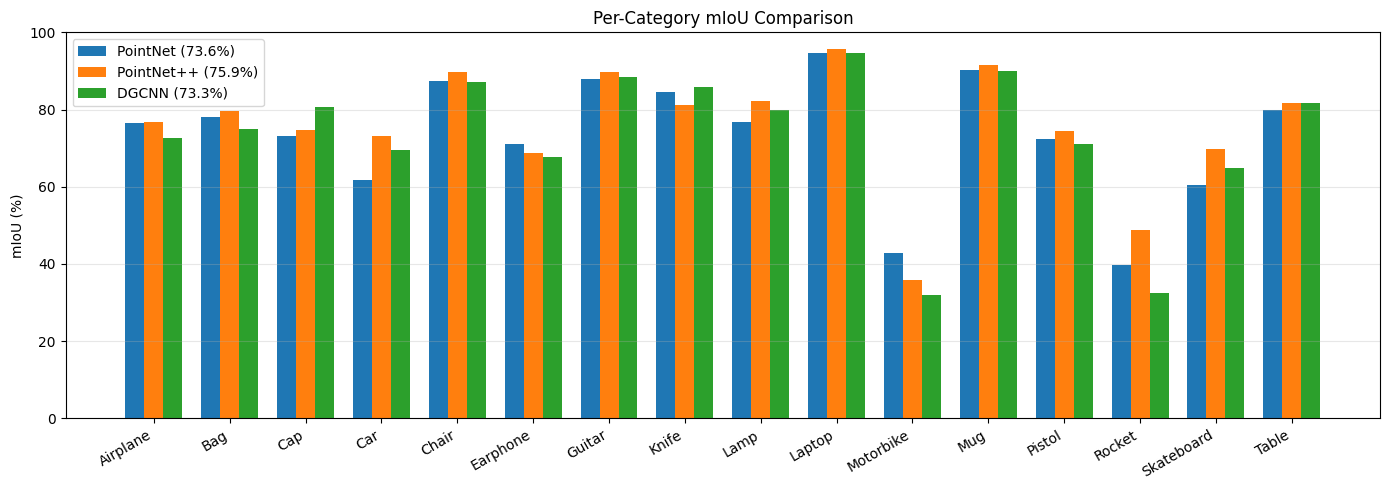

Saved: figures/per_cat_miou.{pdf,png}


In [ ]:
colors = ["tab:blue", "tab:orange", "tab:green"]
cats = ALL_CATEGORIES
x = np.arange(len(cats))
w = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
for i, (name, r) in enumerate(results.items()):
    ious = [r["per_cat"].get(c, 0) * 100 for c in cats]
    ax.bar(x + i * w, ious, w,
           label=f"{name} ({np.mean(ious):.1f}%)", color=colors[i])
ax.set_xticks(x + w)
ax.set_xticklabels(cats, rotation=30, ha="right")
ax.set_ylabel("mIoU (%)")
ax.set_title("Per-Category mIoU Comparison")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()

for ext in ("pdf", "png"):
    plt.savefig(os.path.join(OUT_DIR, "figures", f"per_cat_miou.{ext}"),
                bbox_inches="tight", dpi=150 if ext == "png" else None)
plt.show()
print(f"Saved: figures/per_cat_miou.{{pdf,png}}")


# Training Curves

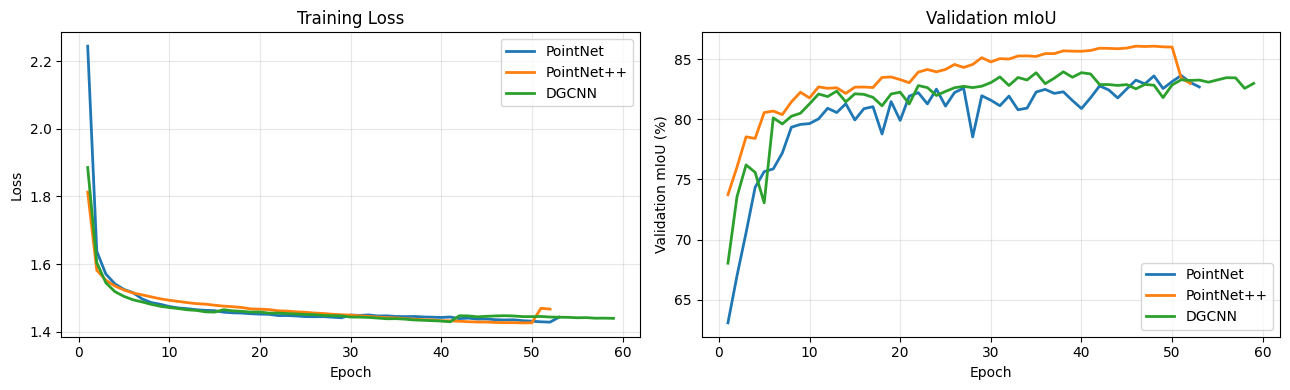

Saved: figures/training_curves.{pdf,png}


In [ ]:
hist_paths = {
    "PointNet":   os.path.join(CKPT_ROOT, "pointnet",  "history.json"),
    "PointNet++": os.path.join(CKPT_ROOT, "pointnet2", "history.json"),
    "DGCNN":      os.path.join(CKPT_ROOT, "dgcnn",     "history.json"),
}
histories = {}
for name, p in hist_paths.items():
    if os.path.exists(p):
        with open(p) as f:
            histories[name] = json.load(f)
    else:
        print(f"[skip] {name}: no history.json at {p}")

if histories:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    for (name, h), c in zip(histories.items(), colors):
        ep = range(1, len(h["train_loss"]) + 1)
        ax1.plot(ep, h["train_loss"], label=name, color=c, linewidth=2)
        ax2.plot(ep, [v * 100 for v in h["val_miou"]],
                 label=name, color=c, linewidth=2)
    ax1.set(xlabel="Epoch", ylabel="Loss", title="Training Loss")
    ax1.legend(); ax1.grid(alpha=0.3)
    ax2.set(xlabel="Epoch", ylabel="Validation mIoU (%)",
            title="Validation mIoU")
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    for ext in ("pdf", "png"):
        plt.savefig(os.path.join(OUT_DIR, "figures", f"training_curves.{ext}"),
                    bbox_inches="tight", dpi=150 if ext == "png" else None)
    plt.show()
    print("Saved: figures/training_curves.{pdf,png}")
else:
    print("No history.json files found — skipping training-curve figure.")


# Point-density Robustness

Model             2048      1024       512       256       128
--------------------------------------------------------------
PointNet        79.92%    80.00%    80.10%    79.76%    78.83%
PointNet++      82.27%    81.76%    75.62%    60.49%    48.34%
DGCNN           80.42%    80.42%    76.86%    69.14%    62.59%


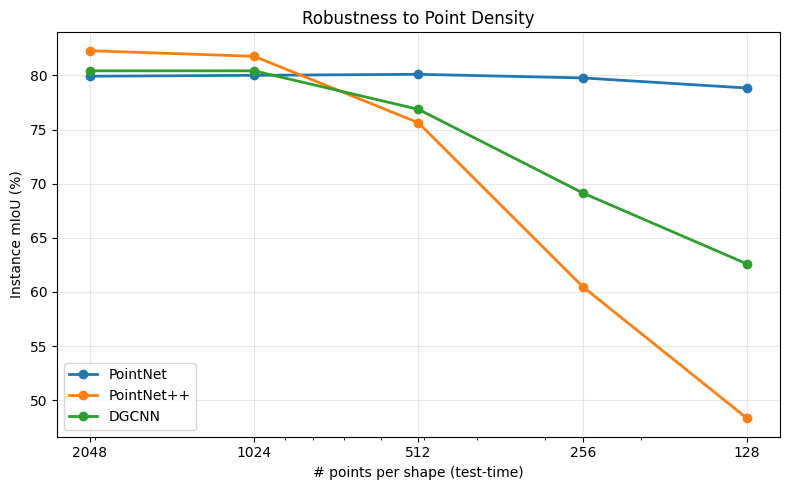


Saved: figures/density_robustness.{pdf,png}
Saved: density_results.json


In [ ]:
@torch.no_grad()
def evaluate_at_density(model, loader, n_points):
    model.eval()
    cat_ious = {i: [] for i in range(NUM_CATEGORIES)}
    for pts, lbl, cats, oh in loader:
        B, N, _ = pts.shape
        idx = torch.stack([torch.randperm(N)[:n_points] for _ in range(B)])
        batch_idx = torch.arange(B).unsqueeze(1).expand(-1, n_points)
        pts_sub = pts[batch_idx, idx]
        lbl_sub = lbl[batch_idx, idx]

        logits = model(pts_sub.to(DEVICE), oh.to(DEVICE))
        preds  = logits.argmax(-1).cpu().numpy()
        lbl_np = lbl_sub.numpy()
        for b in range(preds.shape[0]):
            cat_ious[int(cats[b])].append(
                shape_iou(preds[b], lbl_np[b], int(cats[b])))

    all_ious = []
    for i in range(NUM_CATEGORIES):
        if cat_ious[i]:
            all_ious.extend(cat_ious[i])
    return float(np.mean(all_ious))


densities = [2048, 1024, 512, 256, 128]
density_results = {name: [] for name in models}

print(f"{'Model':<12}" + "".join(f"{d:>10}" for d in densities))
print("-" * (12 + 10 * len(densities)))
for name, model in models.items():
    row = []
    for n in densities:
        miou = evaluate_at_density(model, test_loader, n)
        row.append(miou * 100)
        density_results[name].append(miou * 100)
    print(f"{name:<12}" + "".join(f"{v:>9.2f}%" for v in row))

with open(os.path.join(OUT_DIR, "density_results.json"), "w") as f:
    json.dump({"densities": densities, "results": density_results}, f, indent=2)

# plot
fig, ax = plt.subplots(figsize=(8, 5))
for (name, vals), c in zip(density_results.items(), colors):
    ax.plot(densities, vals, marker="o", label=name, color=c, linewidth=2)
ax.set_xscale("log")
ax.set_xticks(densities); ax.set_xticklabels(densities)
ax.set_xlabel("# points per shape (test-time)")
ax.set_ylabel("Instance mIoU (%)")
ax.set_title("Robustness to Point Density")
ax.legend(); ax.grid(alpha=0.3)
ax.invert_xaxis()  # high → low density reads left-to-right
plt.tight_layout()

for ext in ("pdf", "png"):
    plt.savefig(os.path.join(OUT_DIR, "figures", f"density_robustness.{ext}"),
                bbox_inches="tight", dpi=150 if ext == "png" else None)
plt.show()
print("\nSaved: figures/density_robustness.{pdf,png}")
print("Saved: density_results.json")


# Qualitative Visualization

Got 4 example(s) across 4 categories.


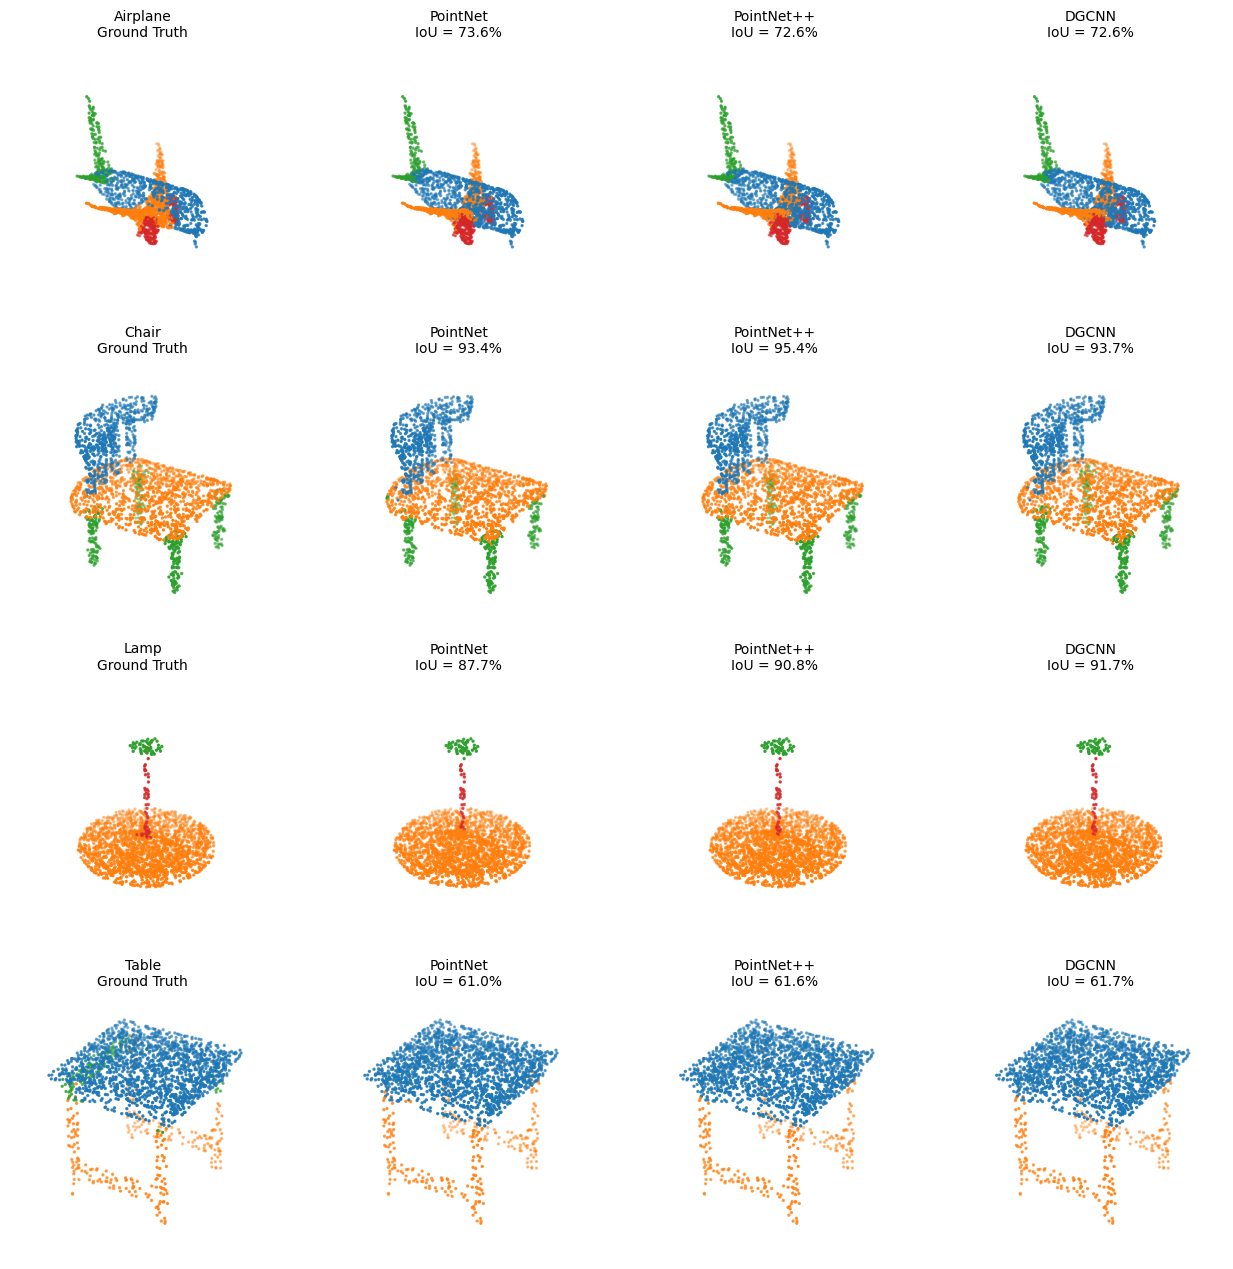

Saved: figures/qualitative.{pdf,png}


In [ ]:
# Render predicted vs. ground-truth
# segmentations for a few test shapes from each model.

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers 3D projection

# chose some categories to show (Airplane, Chair, Lamp, Table)
SHOWCASE_CATS = ['Airplane', 'Chair', 'Lamp', 'Table']
N_PER_CAT = 1  # 1 example per category

# Pull one (or more) test shapes per requested category.
def get_examples(loader, cat_names, n_per_cat=1, max_batches=30):
    target_idxs = {ALL_CATEGORIES.index(c): n_per_cat for c in cat_names}
    found = {i: [] for i in target_idxs}
    for bi, (pts, lbl, cats, oh) in enumerate(loader):
        if bi >= max_batches:
            break
        for b in range(pts.shape[0]):
            ci = int(cats[b])
            if ci in target_idxs and len(found[ci]) < target_idxs[ci]:
                found[ci].append((pts[b], lbl[b], ci, oh[b]))
        if all(len(v) == target_idxs[k] for k, v in found.items()):
            break
    examples = []
    for c in cat_names:
        examples.extend(found[ALL_CATEGORIES.index(c)])
    return examples


@torch.no_grad()
def predict_one(model, pts, oh):
    pts_b = pts.unsqueeze(0).to(DEVICE)
    oh_b  = oh.unsqueeze(0).to(DEVICE)
    return model(pts_b, oh_b).argmax(-1)[0].cpu().numpy()


# Color points by part label, using a fresh-tab10 slice per category.
def plot_cloud(ax, xyz, labels, parts, title):
    cmap = plt.cm.tab10
    # Map global part IDs to local 0..k-1 indices for coloring.
    part_to_local = {p: i for i, p in enumerate(parts)}
    colors = np.array([cmap(part_to_local[int(l)] % 10) for l in labels])
    ax.scatter(xyz[:, 0], xyz[:, 2], xyz[:, 1],  # swap axes for nicer default view
               c=colors, s=2, depthshade=True)
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()
    ax.set_box_aspect([1, 1, 1])


examples = get_examples(test_loader, SHOWCASE_CATS, n_per_cat=N_PER_CAT)
print(f'Got {len(examples)} example(s) across {len(SHOWCASE_CATS)} categories.')

# Layout: rows = examples, cols = (GT | PointNet | PointNet++ | DGCNN)
n_rows = len(examples)
n_cols = 1 + len(models)
fig = plt.figure(figsize=(3.2 * n_cols, 3.2 * n_rows))

for r, (pts, lbl, ci, oh) in enumerate(examples):
    xyz = pts[:, :3].numpy()
    gt = lbl.numpy()
    parts = SEG_CLASSES[ALL_CATEGORIES[ci]]
    cat_name = ALL_CATEGORIES[ci]

    # Ground truth.
    ax = fig.add_subplot(n_rows, n_cols, r * n_cols + 1, projection='3d')
    plot_cloud(ax, xyz, gt, parts, f'{cat_name}\nGround Truth')

    # One column per model.
    for ci_col, (mname, model) in enumerate(models.items(), start=1):
        pred = predict_one(model, pts, oh)
        iou = shape_iou(pred, gt, ci)
        ax = fig.add_subplot(n_rows, n_cols, r * n_cols + 1 + ci_col,
                             projection='3d')
        plot_cloud(ax, xyz, pred, parts, f'{mname}\nIoU = {iou*100:.1f}%')

plt.tight_layout()
for ext in ('pdf', 'png'):
    plt.savefig(os.path.join(OUT_DIR, 'figures', f'qualitative.{ext}'),
                bbox_inches='tight', dpi=150 if ext == 'png' else None)
plt.show()
print('Saved: figures/qualitative.{pdf,png}')